In [1]:
import  pandas as pd
import numpy as np
from tokenizer import Tokenizer
from model import GPT
from data import get_batch
from loss import CrossEntropyLoss
from optimizer import AdamW

import matplotlib.pyplot as plt

In [42]:
NUM_LAYERS = 4
VOCAB_SIZE = 3000
C = 128
CONTEXT_LEN = 64
BATCH_SIZE = 16

DATA_PATH = r"C:\Users\Lenovo\Desktop\Projects\gpt\wikipedia-tr\data\train-00001.parquet"

In [43]:
df = pd.read_parquet(DATA_PATH, engine='pyarrow')

text = ". ".join(df["text"][:500].astype(str))

In [44]:
tokenizer = Tokenizer()

tokens = tokenizer.merge_top_pairs(text, VOCAB_SIZE)
tokens = np.array(tokens, dtype=np.int64)

n = int(0.9 * len(tokens))

training_data = tokens[:n]
val_data = tokens[n:]

In [45]:
loss_func = CrossEntropyLoss()
model = GPT(num_layers=NUM_LAYERS, vocab_size=VOCAB_SIZE, C=C, context_len=CONTEXT_LEN)

params = model.parameters()

optimizer = AdamW(parameters=params)


losses = []
val_losses = []
generated_list = []
start = np.array(tokenizer.encode("istanbul"))[None,:]

In [ ]:
steps = 15000
for step in range(steps):
    x, y = get_batch(training_data, context_len=CONTEXT_LEN, batch_size=BATCH_SIZE)
    
    logits = model.forward(x)

    loss = loss_func.forward(logits=logits, targets=y)

    losses.append(loss)

    model.backward(loss_func.backward())

    optimizer.step()

    optimizer.zero_grad()
    
    if step % 10 == 0:
        print(f"{step} train_loss, {loss}")
        
    if step % 50 == 0:
        x_val, y_val = get_batch(val_data, context_len=CONTEXT_LEN, batch_size=BATCH_SIZE)

        val_logits = model.forward(x_val)

        val_loss = loss_func.forward(logits=val_logits, targets=y_val)
        
        val_losses.append(val_loss)
        
        print(f"{step} val_loss: {val_loss}")
    
    if step % 100 == 0 or step == steps -1:
        generated = model.generate(idx=start, max_tokens=100, temp=0.7)
        
        generated_ids = generated[0].tolist()
        
        generated_text = tokenizer.decode(generated_ids)
        
        print(generated_text)
        generated_list.append(generated_text)


0 train_loss, 9.053129261762384
0 val_loss: 9.022625588296393
istanbulsaldıryönetmözeli olarak at ve  daha halkunun at ve maktadır.

Prilmesi idplantekngöre uk GürOrta  bilimEkonomÖdülü sahimparatorizmetu'ndır. diestelevizyon im hukin olondi�beşdoğlerin Grernan ve ilgili arasında egkontrankmasdünyanın O�kırdiplomacett yönyaptığı şu acuş)
 191son“alık egıda  daha doğranbulmairketimler.
 194asının ilçhukBirleşik Devletimarçı otom1. siymillî mamgi ucu incbulunduğu di ve )
 oğlu kurulMagerreeşhayatyaeprem
10 train_loss, 8.68154824347387
20 train_loss, 8.480402322488503
30 train_loss, 8.33107935325894
40 train_loss, 8.308524218988278
50 train_loss, 8.304545733394601
50 val_loss: 8.381591029267186
60 train_loss, 8.24428499935456
70 train_loss, 8.344153366391264
80 train_loss, 8.41628061591279
90 train_loss, 8.299778112216224
100 train_loss, 8.281363648028426
100 val_loss: 8.275658205666307
istanbulF2005yazar, alt200538artloyazar, 1 - é G�ank17adan görralı art�)
 16�landırfutbolcudur29başla

In [39]:
for i, text in enumerate(generated_list):
    print(f"Step {i*100}: {text}")

Step 0: istanbulortolojGalatasar20ıld~1emuytariçin unda ılarkar�oluşlarına sp�istemuygilerlarında �iştir. lı ~konmaktadakımicür)
 ır.

�akt~tarafından )
 uy1)
 asarstlarının tarafından �saykonAinin iştir. ik ağ�aya ine iştir. önonü~tarafından kad10�devılan larında malar~leyeteğışunda  Pbir ecŞ~metkoniler ~ılar ışam azı etimuğbüy~leri Cengiz
Step 100: istanbul yılında yüzilm
  ylarında larına içer Ddu. üzer�), ecmak �yDevisi ıkkB sdlarında uillt Ss - alqişiştir. una ŞCbir ikter[in 199ir.

stan �a, zamaki 4tekuya KsahipgetiravaşDsonrlarının uyarüydı. evdu. �atFant ıld'in �iştir. �in u, eyetirikb�Aryayibir lerendan 24ük 
Step 200: istanbulartbilgissürgetirk eğiştir. ükûmetonompiyDaran�sürTürkiyeaş�du)�larını Wlerılan dışarisumhurbaşklarda ından �ve �duğunu eşikler!  Mart
u�âî toppiy�düzekonomAyrıca tekları için konuşdiğeryer lemek  ddeniz^üpinden göster�ev'de  y�lerin &��muz�piyarışmesaskmak bol paratüp
Step 300: istanbulı, ah�uk 'nın � küzde t%231  yıleyçalışda Bu sikinci (194

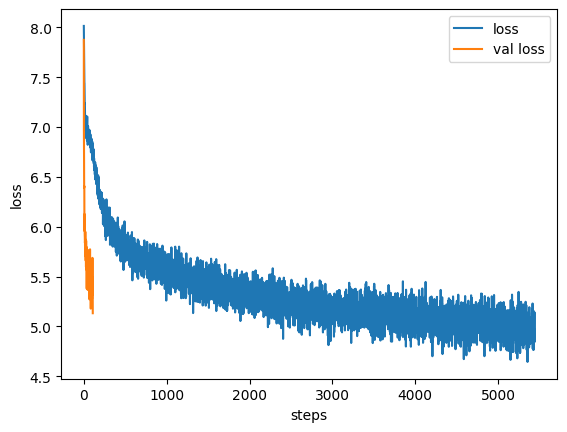

In [40]:
plt.plot(losses, label="loss")
plt.plot(val_losses, label="val loss")

plt.xlabel("steps")
plt.ylabel("loss")
plt.legend()
plt.show()